<a href="https://colab.research.google.com/github/CORT2004/Vision_Artificial_Modelo/blob/main/Detecci%C3%B3n_de_Residuos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Verififcar que el entorno de ejecución GPU este encendido
import torch

print("GPU disponible:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

GPU disponible: True
GPU: Tesla T4


In [2]:
!pip install ultralytics roboflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 82.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 93.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 139.3 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.18
    Uninstalling idna-3.18:
      Successfully uninstalled idna-3.18


In [3]:
from ultralytics import YOLO

print("YOLO instalado correctamente")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLO instalado correctamente


In [4]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="3vDNd23Gfec9bz4snKrf")
project = rf.workspace("victors-workspace-6oatp").project("detector-de-residuos-vscwy")
version = project.version(3)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Detector-de-Residuos-3 in yolov8:: 100%|██████████| 467/467 [00:00<00:00, 8042.82it/s]


In [5]:
import os

os.listdir()

['.config', 'Detector-de-Residuos-3', 'sample_data']

In [6]:
!cat Detector-de-Residuos-1/data.yaml

cat: Detector-de-Residuos-1/data.yaml: No such file or directory


In [5]:
!ls

Detector-de-Residuos-2	sample_data


In [7]:
import os

train_imgs = len(os.listdir("Detector-de-Residuos-3/train/images"))
valid_imgs = len(os.listdir("Detector-de-Residuos-3/valid/images"))
test_imgs = len(os.listdir("Detector-de-Residuos-3/test/images"))

print("Train:", train_imgs)
print("Valid:", valid_imgs)
print("Test:", test_imgs)
print("Total:", train_imgs + valid_imgs + test_imgs)

Train: 215
Valid: 11
Test: 5
Total: 231


In [8]:
#Verififcar balance
from collections import Counter
import os

labels_dir = "Detector-de-Residuos-3/train/labels"

contador = Counter()

for archivo in os.listdir(labels_dir):
    if archivo.endswith(".txt"):
        with open(os.path.join(labels_dir, archivo)) as f:
            for linea in f:
                clase = int(linea.split()[0])
                contador[clase] += 1

print(contador)

Counter({2: 601, 0: 398, 1: 284})


In [9]:
#Iniciar entrenamiento
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data="Detector-de-Residuos-3/data.yaml",
    epochs=100,
    imgsz=640,
    batch=8,
    patience=20,
    device=0
)

Ultralytics 8.4.72 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Detector-de-Residuos-3/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20, 

In [16]:
#Cargar imagen a analizar
from google.colab import files
import os

uploaded = files.upload()
print(os.listdir())

Saving Prueba 2.jpeg to Prueba 2.jpeg
['.config', 'yolov8n.pt', 'Prueba 2.jpeg', 'yolo26n.pt', 'runs', 'Prueba 3.jpeg', 'Detector-de-Residuos-3', 'sample_data']


In [17]:
#Verificar dirección de imagen cargada
!ls /content

 Detector-de-Residuos-3  'Prueba 3.jpeg'   sample_data	 yolov8n.pt
'Prueba 2.jpeg'		  runs		   yolo26n.pt


In [18]:
from ultralytics import YOLO

#Cargar modelo de entrenamiento_carga el archivo que fue entrenado anteriormente
model = YOLO('/content/runs/detect/train/weights/best.pt')

#Analiza la imagen cargada y encuentra los elementos que aprendio a distinguir
results = model.predict(
    source='/content/Prueba 2.jpeg',
    conf=0.25,
    save=True
)


image 1/1 /content/Prueba 2.jpeg: 352x640 3 Botellas, 2 Cartons, 6 Latas, 7.4ms
Speed: 1.9ms preprocess, 7.4ms inference, 1.5ms postprocess per image at shape (1, 3, 352, 640)
Results saved to /content/runs/detect/predict-2



image 1/1 /content/Prueba 2.jpeg: 352x640 3 Botellas, 2 Cartons, 6 Latas, 7.9ms
Speed: 2.0ms preprocess, 7.9ms inference, 1.4ms postprocess per image at shape (1, 3, 352, 640)


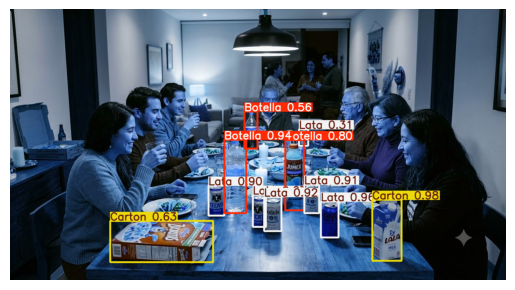


Objetos detectados:
Carton: 2
Lata: 6
Botella: 3


In [20]:
from ultralytics import YOLO
from collections import Counter
import matplotlib.pyplot as plt

model = YOLO('/content/runs/detect/train/weights/best.pt')

results = model('/content/Prueba 2.jpeg')

# Mostrar imagen
img = results[0].plot()
plt.imshow(img)
plt.axis('off')
plt.show()

# Contar objetos
clases = [int(box.cls[0]) for box in results[0].boxes]
conteo = Counter(clases)

print("\nObjetos detectados:")
for clase, cantidad in conteo.items():
    print(f"{model.names[clase]}: {cantidad}")

